In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout ,BatchNormalization , Activation
from tensorflow.keras.regularizers import L1, L2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint ,ReduceLROnPlateau
from tensorflow.keras.optimizers import SGD, Adam
from kerastuner.tuners import RandomSearch
from imblearn.over_sampling import SMOTE,SMOTENC,RandomOverSampler 
from imblearn.combine import SMOTETomek 
from sklearn.utils import class_weight
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from pca import pca

In [2]:
df = pd.read_csv(r"D:\Kareem\Machine learning Developer\9- Deep Learning\Kaggel.csv") # train
dftest = pd.read_csv(r"D:\Kareem\Machine learning Developer\9- Deep Learning\test.csv") # test
df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [3]:
df.loc[:, ["Crop_Type"]].value_counts()

Crop_Type
Sugarcane    108910
Rice         106697
Cotton       104645
Maize        104274
Wheat        103005
Potato       102469
Name: count, dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  str    
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  str    
 12  Crop_Growth_Stage        630000 non-null  str    
 13  Season                   630000 non-null  str    
 14  Irrigation_Type

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,630000.0,314999.500000,181865.479132,0.00,157499.7500,314999.50,472499.25,629999.00
Soil_pH,630000.0,6.482497,0.922504,4.80,5.6900,6.44,7.27,8.20
Soil_Moisture,630000.0,37.304482,16.377082,8.00,23.3400,37.75,51.27,64.99
Organic_Carbon,630000.0,0.922858,0.365808,0.30,0.6100,0.91,1.22,1.60
Electrical_Conductivity,630000.0,1.744605,0.952321,0.10,0.9300,1.74,2.58,3.50
Temperature_C,630000.0,26.998166,8.623621,12.00,19.5175,26.96,34.54,42.00
Humidity,630000.0,61.563180,19.708152,25.00,45.3900,61.65,79.12,94.99
Rainfall_mm,630000.0,1462.207566,612.989738,0.38,954.5700,1467.16,2054.28,2499.69
Sunlight_Hours,630000.0,7.513382,1.999322,4.00,5.7600,7.58,9.25,11.00
Wind_Speed_kmh,630000.0,10.375394,5.689458,0.50,5.2800,10.48,15.43,20.00


In [6]:
df.isnull().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [7]:
print(df.duplicated().sum())

0


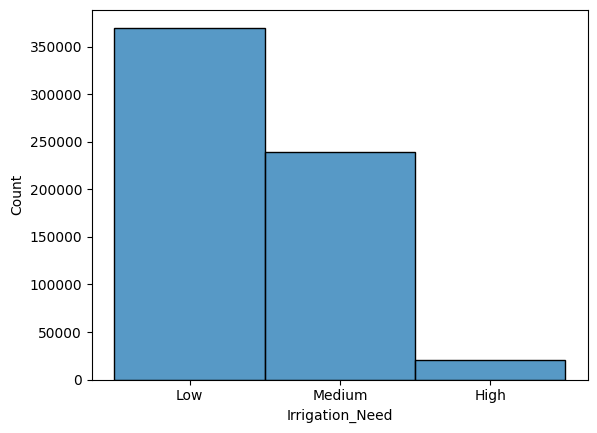

In [8]:
sns.histplot(x="Irrigation_Need",data=df)
plt.show()

In [9]:
mapp = {'Low': 0, 'Medium': 1, 'High': 2}
df['Irrigation_Need'] = df['Irrigation_Need'].map(mapp)

In [10]:
def feature(df):
    # Feature Engineering
    df['sun_temp'] = df['Temperature_C'] + df['Sunlight_Hours'] + df['Electrical_Conductivity']
    df['sun_temp_mois'] = df['Soil_Moisture'] / (df['sun_temp'] )  
    df['Humidity_rain']  = df['Humidity'] / df['Rainfall_mm']
    df["moisture_Temp"] = df["Soil_Moisture"] * df["Temperature_C"]
    df["rain_moisture"] = df["Rainfall_mm"] * df["Soil_Moisture"]   
    df['moisture_humidity'] =df['Soil_Moisture']  * df['Humidity']
    df['temp_soil'] = df['Temperature_C'] / df['Soil_Moisture']
    df['pre_irr_plus_Rain'] = df['Previous_Irrigation_mm'] + df['Rainfall_mm']
    df['Temp_humid'] = df['Temperature_C'] - df['Humidity']
    df['vvaporation'] = (df['Temperature_C'] / df['Soil_Moisture'] )*100
    df['water in the soil'] = (df['Rainfall_mm'] / df['Soil_Moisture'] )*100
    df["the_evaporative"] = (df["Temperature_C"]* df["Sunlight_Hours"]* (df["Wind_Speed_kmh"] + 1) ) / (df["Humidity"] + 10)
    df['temp_Wind'] = (df['Temperature_C'] + df['Wind_Speed_kmh']) / df['Soil_Moisture'] + 1
    df["Water_Deficit"] = df["pre_irr_plus_Rain"] - df["the_evaporative"]
    df["Irrigation_Area"] = df["Previous_Irrigation_mm"] * df["Field_Area_hectare"]

    df.drop(['Field_Area_hectare'], axis=1, inplace=True)

    return df

In [11]:
# Feature Engineering
df = feature(df)
dftest = feature(dftest)

In [12]:
cat_cols = ['Soil_Type','Crop_Type','Irrigation_Type','Water_Source','Season','Crop_Growth_Stage','Mulching_Used', 'Region']

df = pd.get_dummies(df, columns=cat_cols)
dftest = pd.get_dummies(dftest, columns=cat_cols)

df, dftest = df.align(dftest, join='left', axis=1, fill_value=0)


In [14]:
X = df.drop(["Irrigation_Need","id"],axis=1)
y = df['Irrigation_Need']
X_train , X_test , y_train , y_test = train_test_split(X ,y ,train_size=0.8 ,random_state=42 , stratify=y)

In [15]:
num_cols = [
    'Soil_pH','Soil_Moisture','Organic_Carbon','Electrical_Conductivity',
    'Temperature_C','sun_temp','sun_temp_mois','Humidity_rain','moisture_humidity','moisture_Temp',
    'Wind_Speed_kmh','Water_Deficit','rain_moisture','temp_Wind','water in the soil','the_evaporative','temp_soil','pre_irr_plus_Rain','water in the soil','vvaporation','Temp_humid','Irrigation_Area','Rainfall_mm'
]

scl = StandardScaler()
X_train[num_cols] = scl.fit_transform(X_train[num_cols])  
X_test[num_cols] = scl.transform(X_test[num_cols])
dftest[num_cols]  = scl.transform(dftest[num_cols])
df

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,...,Crop_Growth_Stage_Harvest,Crop_Growth_Stage_Sowing,Crop_Growth_Stage_Vegetative,Mulching_Used_No,Mulching_Used_Yes,Region_Central,Region_East,Region_North,Region_South,Region_West
0,0,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,...,False,True,False,True,False,False,True,False,False,False
1,1,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,...,False,False,True,False,True,False,False,False,True,False
2,2,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,...,False,False,True,False,True,False,False,True,False,False
3,3,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,...,False,False,False,False,True,False,False,False,True,False
4,4,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,...,False,True,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,6.54,13.45,1.15,1.86,26.65,26.86,1041.33,10.62,18.85,...,False,True,False,True,False,False,False,False,True,False
629996,629996,7.03,54.49,0.96,2.35,36.99,88.00,1419.57,9.93,17.99,...,False,False,True,False,True,True,False,False,False,False
629997,629997,6.52,11.98,0.93,0.38,37.82,70.98,88.45,8.19,17.25,...,False,False,True,False,True,False,False,False,True,False
629998,629998,5.93,42.86,0.33,3.39,34.99,94.58,2433.92,9.88,5.00,...,False,False,True,False,True,False,True,False,False,False


In [16]:
print(X_train.columns.tolist())

['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Previous_Irrigation_mm', 'sun_temp', 'sun_temp_mois', 'Humidity_rain', 'moisture_Temp', 'rain_moisture', 'moisture_humidity', 'temp_soil', 'pre_irr_plus_Rain', 'Temp_humid', 'vvaporation', 'water in the soil', 'the_evaporative', 'temp_Wind', 'Water_Deficit', 'Irrigation_Area', 'Soil_Type_Clay', 'Soil_Type_Loamy', 'Soil_Type_Sandy', 'Soil_Type_Silt', 'Crop_Type_Cotton', 'Crop_Type_Maize', 'Crop_Type_Potato', 'Crop_Type_Rice', 'Crop_Type_Sugarcane', 'Crop_Type_Wheat', 'Irrigation_Type_Canal', 'Irrigation_Type_Drip', 'Irrigation_Type_Rainfed', 'Irrigation_Type_Sprinkler', 'Water_Source_Groundwater', 'Water_Source_Rainwater', 'Water_Source_Reservoir', 'Water_Source_River', 'Season_Kharif', 'Season_Rabi', 'Season_Zaid', 'Crop_Growth_Stage_Flowering', 'Crop_Growth_Stage_Harvest', 'Crop_Growth_Stage_Sowing', 'Crop_Growth_Stage_Vegetative', 

In [ ]:


weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(weights))

smtom = SMOTETomek(
    smote=SMOTE(
        sampling_strategy={2: 160000},
        random_state=42,
        k_neighbors=5
    ),
    random_state=42
)
X_train_res, y_train_res = smtom.fit_resample(X_train, y_train)
print("After SMOTE:", Counter(y_train_res))

In [52]:
from tensorflow.keras.layers import LeakyReLU

model = Sequential([
    Dense(512, input_shape=(X_train_res.shape[1],), kernel_regularizer=L2(0.0001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.01),

    Dense(256, kernel_regularizer=L2(0.0001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.01),

    Dense(128, kernel_regularizer=L2(0.0001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.01),

    Dense(64, kernel_regularizer=L2(0.0001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.01),

    Dense(3, activation='softmax')
])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 512)            │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,211 (805.51 KB)

 Trainable params: 204,291 (798.01 KB)

 Non-trainable params: 1,920 (7.50 KB)

In [53]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

model.fit(
    X_train_res, y_train_res,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=300,
    class_weight=class_weight_dict,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/100
1989/1999 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8577 - loss: 0.4189
Epoch 1: val_loss improved from None to 0.24130, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1999/1999 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9098 - loss: 0.2918 - val_accuracy: 0.9278 - val_loss: 0.2413 - learning_rate: 0.0010
Epoch 2/100
1995/1999 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9457 - loss: 0.2012
Epoch 2: val_loss improved from 0.24130 to 0.22818, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1999/1999 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9491 - loss: 0.1911 - val_accuracy: 0.9318 - val_loss: 0.2282 - learning_rate: 0.0010
Epoch 3/100
1992/1999 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9582 - loss: 0.1643
Epoch 3: val_loss improved from 0.22818 to 0.19589, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
1999/1999 ━━━━━━━━━━━━━━━━━━━━ 11s 5m

In [55]:
model.evaluate(X_test,y_test)

3938/3938 ━━━━━━━━━━━━━━━━━━━━ 3s 735us/step - accuracy: 0.9753 - loss: 0.0932


[0.09320325404405594, 0.9753254055976868]

In [56]:
model.evaluate(X_train_res,y_train_res)

18733/18733 ━━━━━━━━━━━━━━━━━━━━ 15s 808us/step - accuracy: 0.9839 - loss: 0.0633


[0.0632869228720665, 0.9839252829551697]

In [57]:
from sklearn.metrics import balanced_accuracy_score

y_pred_proba = model.predict(X_test)   
y_pred = np.argmax(y_pred_proba, axis=1)

bal_acc = balanced_accuracy_score(y_test, y_pred)  
print(f"Balanced Accuracy on Test Set: {bal_acc:.4f}")

3938/3938 ━━━━━━━━━━━━━━━━━━━━ 2s 617us/step
Balanced Accuracy on Test Set: 0.9606


In [58]:
dftest

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,...,Crop_Growth_Stage_Harvest,Crop_Growth_Stage_Sowing,Crop_Growth_Stage_Vegetative,Mulching_Used_No,Mulching_Used_Yes,Region_Central,Region_East,Region_North,Region_South,Region_West
0,630000,-0.133705,-0.679799,-0.910030,1.120216,-1.063342,30.24,0.114901,5.40,-1.296856,...,False,True,False,False,True,False,False,False,False,True
1,630001,-0.664997,-1.675649,0.702261,1.592923,-0.674837,78.07,-1.447187,7.22,0.967055,...,False,True,False,False,True,False,False,False,True,False
2,630002,-0.285503,-0.657818,0.101068,-0.938685,-0.014958,60.35,-1.497362,9.43,-1.361890,...,False,True,False,False,True,False,True,False,False,False
3,630003,1.297530,0.992570,-0.254183,-1.253823,1.709542,36.05,-0.411082,6.69,-1.497233,...,True,False,False,True,False,False,False,True,False,False
4,630004,-1.358929,1.324724,-1.046665,0.384894,1.633000,52.47,-0.230157,4.11,-0.820520,...,False,True,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269995,899995,-0.925222,0.889994,-0.664088,0.878610,0.727261,72.09,1.409226,7.09,-0.062954,...,False,False,True,False,True,False,True,False,False,False
269996,899996,1.471014,0.478465,-0.199529,-0.739097,0.063903,45.16,1.402307,5.15,-0.836340,...,False,False,True,False,True,False,False,False,False,True
269997,899997,1.460171,-1.606043,1.740687,0.164298,-0.418540,64.87,-0.760774,10.44,-0.069985,...,False,False,True,False,True,False,True,False,False,False
269998,899998,0.690340,-1.657331,1.084839,0.952142,1.634160,58.04,-0.542141,5.11,-1.567541,...,True,False,False,False,True,False,True,False,False,False


In [ ]:
sub = dftest[['id']].copy()


cols_to_drop = [c for c in ['id', 'Irrigation_Need'] if c in dftest.columns]
dftest_clean = dftest.drop(cols_to_drop, axis=1)

dftest_clean = dftest_clean[X_train_res.columns]

print(f"dftest columns: {dftest_clean.shape[1]}")
print(f"model expects: {X_train_res.shape[1]}")

y_pred_sub = model.predict(dftest_clean)
y_pred_sub = np.argmax(y_pred_sub, axis=1)
print(y_pred_sub)

dftest columns: 57
model expects: 57
8438/8438 ━━━━━━━━━━━━━━━━━━━━ 5s 601us/step
[0 0 0 ... 1 0 1]


In [61]:
sub['Irrigation_Need'] = y_pred_sub
y_pred_sub

array([0, 0, 0, ..., 1, 0, 1], shape=(270000,))

In [62]:
mappp = {0:'Low', 1:'Medium', 2:'High'}
sub['Irrigation_Need'] = sub['Irrigation_Need'].map(mappp)

In [63]:
sub.to_csv("after96.06.csv", index=False)